In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal , Annotated
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
  

In [2]:
class JokeState(TypedDict):
    topic: str
    joke : str
    explanation : str

In [4]:
llm = ChatOllama(model="Phi3")

In [5]:
def generator_joke (state : JokeState) -> JokeState:
    
    prompt = f'generate a joke about {state["topic"]}' 
    response = llm.invoke(prompt).content

    return {'joke' : response }

In [6]:
def generator_explanation ( state : JokeState):
    
    prompt = f'write an explanation for the joke - {state["joke"]}' 
    response = llm.invoke(prompt).content

    return {'explanation' : response }

In [7]:
graph = StateGraph(JokeState)

graph.add_node('generator_joke', generator_joke)
graph.add_node('generator_explanation', generator_explanation)


graph.add_edge(START, 'generator_joke')
graph.add_edge('generator_joke', 'generator_explanation')
graph.add_edge('generator_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer = checkpointer)


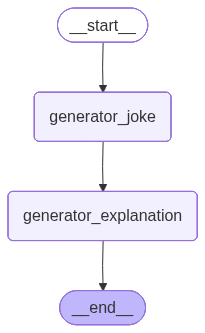

In [8]:
workflow